In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


path = "dataset/prep_time_dataset.csv" # paste dataset path here

df = pd.read_csv(path)

#preview data
df.head()

ModuleNotFoundError: No module named 'seaborn'

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   storeid                  50000 non-null  int64  
 1   requested_delivery_time  49250 non-null  str    
 2   cuisine_group            49000 non-null  str    
 3   number_of_items          48000 non-null  float64
 4   city                     48500 non-null  str    
 5   country                  49000 non-null  str    
 6   latitude                 48750 non-null  float64
 7   longitude                48750 non-null  float64
 8   store_age                48250 non-null  float64
 9   prep_time_minutes        49000 non-null  float64
dtypes: float64(5), int64(1), str(4)
memory usage: 3.8 MB


In [3]:
df.describe()

,storeid,number_of_items,latitude,longitude,store_age,prep_time_minutes
count,50000.000000,48000.000000,48750.000000,48750.000000,48250.000000,49000.000000
mean,550707.113160,4.891083,27.311053,40.082115,2.679080,26.697425
std,249199.275592,15.859370,4.189162,5.238615,2.615381,42.249401
min,106626.000000,-5.000000,0.000000,0.000000,0.100000,0.010944
25%,345017.000000,3.000000,24.523370,35.908890,1.200000,13.649909
50%,545558.000000,4.000000,26.415370,39.213940,2.300000,21.413034
75%,763226.000000,6.000000,31.990750,39.965800,3.500000,33.168733
max,996495.000000,857.000000,50.222580,50.263650,119.939543,2722.608585


In [4]:
# check how many unique stores we have
df["storeid"].nunique()

350

## 2. Data Cleaning

### 2.1 Check for Duplicate Data

In [5]:
# check total number of duplicated rows 
print(f'Number of duplicates in this dataset: {df.duplicated().sum()}')

Number of duplicates in this dataset: 0


### 2.2 Check for Missing Data

In [6]:
# this loops over the columns and prints the column name if it has missing values with the number of missing values
for i in df:
    if df[i].isnull().sum()>0:
        print(f'{i} has: {df[i].isnull().sum()} missing values')

requested_delivery_time has: 750 missing values
cuisine_group has: 1000 missing values
number_of_items has: 2000 missing values
city has: 1500 missing values
country has: 1000 missing values
latitude has: 1250 missing values
longitude has: 1250 missing values
store_age has: 1750 missing values
prep_time_minutes has: 1000 missing values


#### 2.2.1 Missing ``longitude`` and ``latitude`` data

In [7]:
# create a dummy dataframe with missing longitude or latitude data or both
missing_coords = df[df["latitude"].isna() | df["longitude"].isna()]
missing_coords.head()

,storeid,requested_delivery_time,cuisine_group,number_of_items,city,country,latitude,longitude,store_age,prep_time_minutes
7,697881,2025-04-12 17:10:00,quick restaurant service,7.0,Mecca,Saudi Arabia,NaN,39.97843,11.4,13.885888
22,282464,2025-03-22 20:29:00,quick restaurant service,5.0,Riyadh,Saudi Arabia,24.76858,NaN,1.1,17.524223
51,689113,2025-05-24 13:20:00,restaurant,7.0,Irbid,Jordan,NaN,35.87187,1.4,68.209874
64,168708,2025-03-21 18:25:00,delivery,5.0,Irbid,Jordan,32.55611,NaN,4.4,31.168288
70,727093,2025-03-08 00:34:00,delivery,3.0,Irbid,Jordan,32.50001,NaN,0.2,25.996083


In [8]:
len(missing_coords)

2467

The fact that this dataframe has 2467 rows tells us that the vast majority of the missing values belong to different rows and only a few orders are missing both simultanuosly. A store's physical location never changes. Let's check if rows with missing longitude or latitude values belong to a stores that have other orders with valid coordinates.

In [9]:
df["latitude"] = df.groupby("storeid")["latitude"].transform(lambda x: x.fillna(x.mean()))
df["longitude"] = df.groupby("storeid")["longitude"].transform(lambda x: x.fillna(x.mean()))

In [10]:
print(f'{"Longitude"} has: {df["longitude"].isnull().sum()} missing values')
print(f'{"Latitude"} has: {df["longitude"].isnull().sum()} missing values')

Longitude has: 0 missing values
Latitude has: 0 missing values


#### 2.2.2 Missing ``Country`` or ``City`` Data

In [11]:
df["city"].value_counts()

city
Dammam    6646
Medina    6106
Irbid     5742
Zarqa     5667
Amman     5392
Riyadh    5259
Jeddah    4694
Mecca     4687
Aqaba     4307
Name: count, dtype: int64

In [12]:
missing_location = df[df["city"].isna() | df["country"].isna()]
missing_location.head()

,storeid,requested_delivery_time,cuisine_group,number_of_items,city,country,latitude,longitude,store_age,prep_time_minutes
23,213652,2025-01-04 19:18:00,restaurant,6.0,NaN,Saudi Arabia,24.73865,46.71234,1.1,40.494257
39,805507,2025-05-02 15:13:00,delivery,5.0,Irbid,NaN,32.50759,35.90889,0.8,15.273194
49,523986,2025-01-29 18:46:00,delivery,5.0,Riyadh,NaN,24.74199,46.69467,2.6,48.704150
74,646476,2025-03-17 23:22:00,quick restaurant service,2.0,Zarqa,NaN,31.99012,36.04991,2.3,15.226480
77,389093,NaN,restaurant,3.0,Medina,NaN,24.51624,39.66018,2.7,33.822514


In [13]:
city_to_country = {
    "Dammam": "Saudi Arabia",
    "Medina": "Saudi Arabia",
    "Riyadh": "Saudi Arabia",
    "Mecca": "Saudi Arabia",
    "Amman": "Jordan",
    "Zarqa": "Jordan",
    "Irbid": "Jordan",
    "Aqaba": "Jordan"
}

In [14]:
store_lookup = df.groupby("storeid").agg({
    "city": lambda x: x.mode()[0] if not x.mode().empty else None,
    "country": lambda x: x.mode()[0] if not x.mode().empty else None
}).reset_index()

In [15]:
store_to_city = dict(zip(store_lookup["storeid"], store_lookup["city"]))
store_to_country = dict(zip(store_lookup["storeid"], store_lookup["country"]))

In [16]:
df["city"] = df["city"].fillna(df["storeid"].map(store_to_city))

In [17]:
df["country"] = df["country"].fillna(df["storeid"].map(store_to_country))

In [18]:
df[["city", "country"]].isna().sum()

city       0
country    0
dtype: int64

In [19]:
print(f'{"city"} has: {df["city"].isnull().sum()} missing values')
print(f'{"country"} has: {df["country"].isnull().sum()} missing values')

city has: 0 missing values
country has: 0 missing values


#### 2.2.3 Missing ``cuisine_group`` data

In [20]:
df.groupby("storeid")["cuisine_group"].nunique().sort_values(ascending=False)

storeid
106626    1
694538    1
704010    1
702831    1
701561    1
         ..
405049    1
400861    1
398411    1
397176    1
996495    1
Name: cuisine_group, Length: 350, dtype: int64

In [21]:
df["cuisine_group"] = df["cuisine_group"].fillna(df.groupby("storeid")["cuisine_group"].transform(lambda x: x.mode()[0] if not x.mode().empty else None)
)

In [22]:
df["cuisine_group"].isna().sum()

np.int64(0)

In [23]:
print(f'{"cuisine_group"} has: {df["cuisine_group"].isnull().sum()} missing values')

cuisine_group has: 0 missing values


#### 2.2.4 Missing ``store_age`` data

The column ``store_age`` has 1,750 missing values. Additionally, this feature clearly has some unreasonable values with a maximum value of ``119.939543`` which is not plausible given the context. So in essence, there are two problems to be addressed: the missing values and the unreasonable values, both of which can be approximated if they belong to stores that have other orders where this value is available. The strategy I will follow for this column is as follows:
1. Check whether the missing values in ``store_age`` follow any pattern. Particulary, I will check whether missing values are concentrated in specific stores or whether they occur in stores that have valid ``store_age`` values in other records. If a store has at least some valid ``store_age`` entries, the feature can likely be recovered by aggregating at the store level, since store age should be approximately constant for a given store over a short time window. Which brings me to the next question.
2. Is the ``store_age`` value consistent for each ``storeid``? Logically, ``store_age`` is a function of time, which means it is expected to increase gradually with time. 
3. What is the time interval of this data? Understanding the duration over which the data was collected is essential for interpreting ``store_age``, as it allows us to determine whether observed variation is realistic or indicative of feature corruption.


In [24]:
df["store_age"].describe()

count    48250.000000
mean         2.679080
std          2.615381
min          0.100000
25%          1.200000
50%          2.300000
75%          3.500000
max        119.939543
Name: store_age, dtype: float64

In [25]:
stores_missing_age = df[df["store_age"].isna()]["storeid"].unique()
total_stores = df["storeid"].nunique()

len(stores_missing_age), total_stores

(348, 350)

In [26]:
df[df["store_age"].isna()]["storeid"].value_counts().head(10)

storeid
348893    12
389093    11
870951    10
803409    10
914978    10
733628    10
226201    10
666787    10
844867    10
185225     9
Name: count, dtype: int64

In [27]:
stores_with_age = df[df["store_age"].notna()]["storeid"].unique()

len(set(stores_missing_age) & set(stores_with_age))

348

In [28]:
age_range = df.groupby("storeid")["store_age"].agg(["min", "max"])
age_range["diff"] = age_range["max"] - age_range["min"]

In [29]:
valid_stores = age_range[age_range["diff"] <= 0.5].index
invalid_stores = age_range[age_range["diff"] > 0.5].index

In [30]:
len(valid_stores), len(invalid_stores)

(332, 18)

In [31]:
df["requested_delivery_time"] = pd.to_datetime(df["requested_delivery_time"])
df["requested_delivery_time"].min(), df["requested_delivery_time"].max()

(Timestamp('2025-01-01 00:05:00'), Timestamp('2025-05-30 23:52:00'))

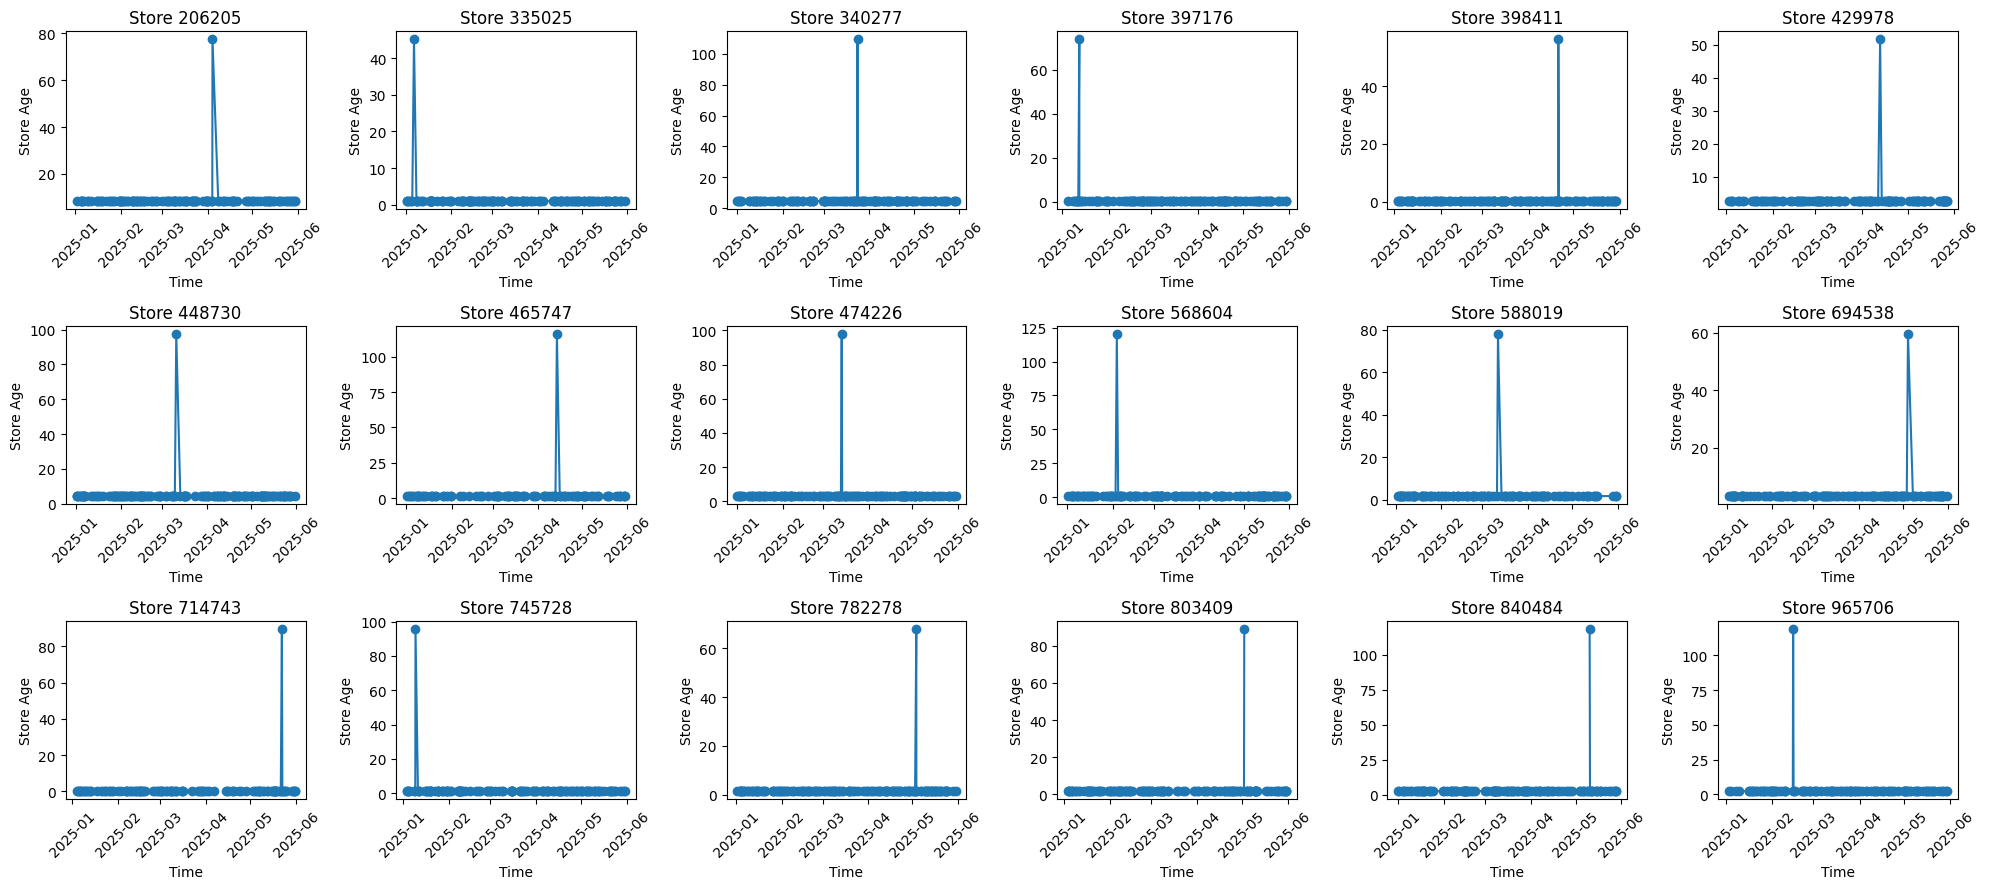

In [32]:
n = len(invalid_stores)

# choosing grid size
ncols = 6
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(20, 3 * nrows), sharex=False, sharey=False)

axes = axes.flatten()  # to make indexing easy

for i, store in enumerate(invalid_stores):
    temp = df[df["storeid"] == store].sort_values("requested_delivery_time")

    ax = axes[i]
    ax.plot(temp["requested_delivery_time"], temp["store_age"], marker="o")

    ax.set_title(f"Store {store}")
    ax.set_xlabel("Time")
    ax.set_ylabel("Store Age")
    ax.tick_params(axis='x', rotation=45)

# turn off empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [33]:
store_median = df.groupby("storeid")["store_age"].transform("median")

In [34]:
mask = df["storeid"].isin(invalid_stores)
df.loc[mask, "store_age"] = store_median[mask]

In [35]:
df["store_age"].describe()

count    48334.000000
mean         2.647126
std          2.000141
min          0.100000
25%          1.200000
50%          2.300000
75%          3.500000
max         11.400000
Name: store_age, dtype: float64

In [36]:
mask2 = df["store_age"].isna()
df.loc[mask2, "store_age"] = store_median[mask2]

In [37]:
df["store_age"].describe()

count    50000.000000
mean         2.646962
std          2.001241
min          0.100000
25%          1.200000
50%          2.300000
75%          3.500000
max         11.400000
Name: store_age, dtype: float64

In [38]:
print(f'{"store_age"} has: {df["store_age"].isnull().sum()} missing values')

store_age has: 0 missing values


#### 2.2.5 Missing ``prep_time_minutes`` and ``requested_delivery_time`` data

In [39]:
print(f'{"prep_time_minutes"} has: {df["prep_time_minutes"].isnull().sum()} missing values')
print(f'{"requested_delivery_time"} has: {df["requested_delivery_time"].isnull().sum()} missing values')

prep_time_minutes has: 1000 missing values
requested_delivery_time has: 750 missing values


Since ``prep_time_minutes`` is the target variable, imputing it would mean training on fabricated labels, which directly corrupts the model. So the strategy here is pretty straight forward: I will drop the 1,000 rows with missing values.

In [40]:
df = df.dropna(subset=["prep_time_minutes"])

In [41]:
print(f'{"prep_time_minutes"} has: {df["prep_time_minutes"].isnull().sum()} missing values')
print(f'{"requested_delivery_time"} has: {df["requested_delivery_time"].isnull().sum()} missing values')

prep_time_minutes has: 0 missing values
requested_delivery_time has: 731 missing values


After dropping the rows with missing ``prep_time_minutes`` values, we still have 731 rows with missing ``requested_delivery_time`` values. The strategy for this column is also similar. This is because there's no way to reconstruct a timestamp and since this feature is crucial for our prediction, I will also be dropping these rows.

In [42]:
df = df.dropna(subset=["requested_delivery_time"])

In [43]:
print(f'{"prep_time_minutes"} has: {df["prep_time_minutes"].isnull().sum()} missing values')
print(f'{"requested_delivery_time"} has: {df["requested_delivery_time"].isnull().sum()} missing values')

prep_time_minutes has: 0 missing values
requested_delivery_time has: 0 missing values


In [44]:
df.shape

(48269, 10)

#### 2.2.6 Missing ``number_of_items`` data

In [45]:
print(f'{"number_of_items"} has: {df["number_of_items"].isnull().sum()} missing values')

number_of_items has: 1935 missing values


In [46]:
df["number_of_items"].describe()

count    46334.000000
mean         4.899642
std         16.064708
min         -5.000000
25%          3.000000
50%          4.000000
75%          6.000000
max        857.000000
Name: number_of_items, dtype: float64

Before addressing the missing values, here are some things to note:

1. Negative value for minimum. This is obviously unreasonable. is it the only negative value or are there more?
2. Outlier valie of 857. This could be a catering situation. However it seems to be the only one. Is the prep time for this order reasonable give the huge order? One would expect it to be proportionally huge. If it isn't, then it might be an error and would introduce bias to our model.

<Axes: xlabel='number_of_items'>

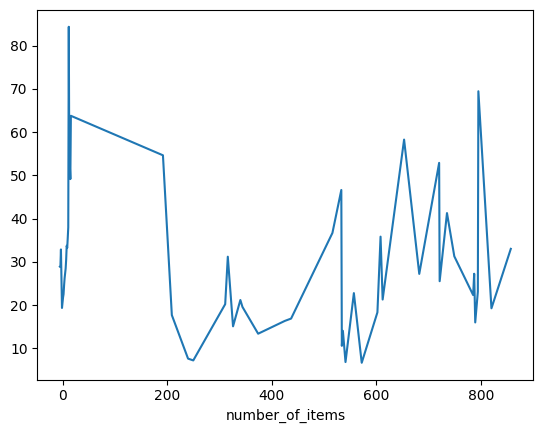

In [47]:
df.groupby("number_of_items")["prep_time_minutes"].mean().plot()

In [48]:
min_val = df["number_of_items"].min()
max_val = df["number_of_items"].max()

bins = np.arange(-100 , max_val + 100, 100)

df["items_bin"] = pd.cut(df["number_of_items"], bins=bins, right=False)

bin_counts = df["items_bin"].value_counts().sort_index()
bin_counts

items_bin
[-100.0, 0.0)        15
[0.0, 100.0)      46284
[100.0, 200.0)        1
[200.0, 300.0)        3
[300.0, 400.0)        6
[400.0, 500.0)        2
[500.0, 600.0)        7
[600.0, 700.0)        5
[700.0, 800.0)        9
[800.0, 900.0)        2
Name: count, dtype: int64

In [49]:
normal_orders = df[(df["number_of_items"] <= 100) & (df["number_of_items"] > 0)]

<Axes: xlabel='number_of_items'>

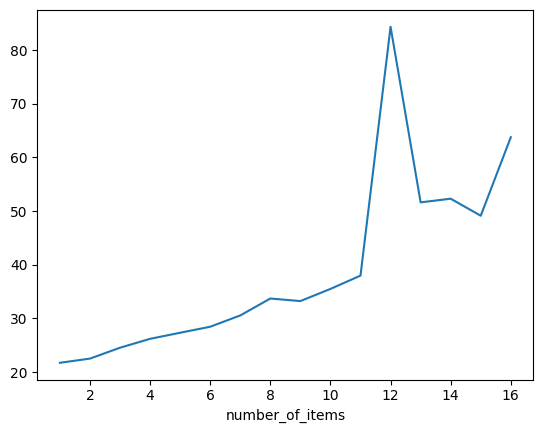

In [50]:
normal_orders.groupby("number_of_items")["prep_time_minutes"].mean().plot()

In [51]:
# fix invalid values
df.loc[df["number_of_items"] <= 0, "number_of_items"] = np.nan

# impute
df["number_of_items"] = df["number_of_items"].fillna(
    df.groupby("storeid")["number_of_items"].transform("median")
)

df["number_of_items"] = df["number_of_items"].fillna(df["number_of_items"].median())

In [52]:
min_val = df["number_of_items"].min()
max_val = df["number_of_items"].max()

bins = np.arange(-100 , max_val + 100, 100)

df["items_bin"] = pd.cut(df["number_of_items"], bins=bins, right=False)

bin_counts = df["items_bin"].value_counts().sort_index()
bin_counts

items_bin
[-100.0, 0.0)         0
[0.0, 100.0)      48234
[100.0, 200.0)        1
[200.0, 300.0)        3
[300.0, 400.0)        6
[400.0, 500.0)        2
[500.0, 600.0)        7
[600.0, 700.0)        5
[700.0, 800.0)        9
[800.0, 900.0)        2
Name: count, dtype: int64

<Axes: xlabel='number_of_items'>

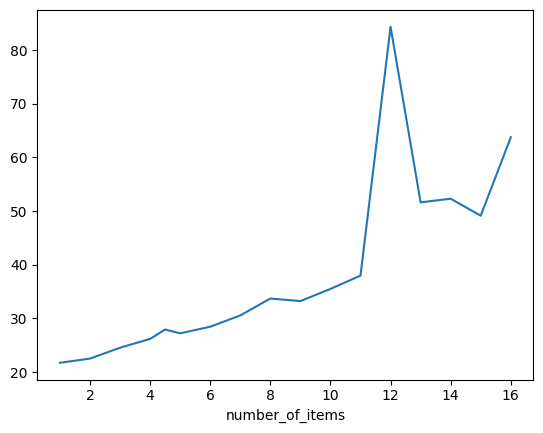

In [53]:
normal_orders = df[(df["number_of_items"] <= 100) & (df["number_of_items"] > 0)]
normal_orders.groupby("number_of_items")["prep_time_minutes"].mean().plot()

<Axes: xlabel='number_of_items'>

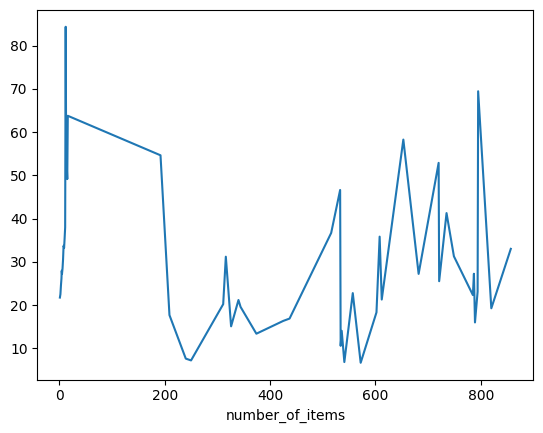

In [54]:
df.groupby("number_of_items")["prep_time_minutes"].mean().plot()

In [55]:
df = df[df["number_of_items"] <= 100]

<Axes: xlabel='number_of_items'>

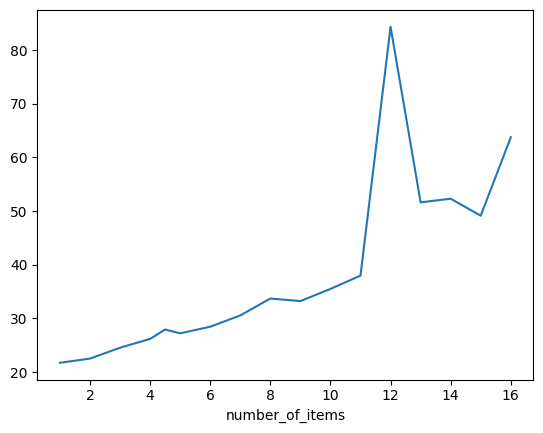

In [56]:
df.groupby("number_of_items")["prep_time_minutes"].mean().plot()

In [57]:
df["number_of_items"].describe()

count    48234.000000
mean         4.476334
std          1.878033
min          1.000000
25%          3.000000
50%          4.000000
75%          6.000000
max         16.000000
Name: number_of_items, dtype: float64

In [58]:
df = df.drop(columns=["items_bin"])
df # sanity check

,storeid,requested_delivery_time,cuisine_group,number_of_items,city,country,latitude,longitude,store_age,prep_time_minutes
0,257666,2025-02-09 20:37:00,quick restaurant service,4.0,Dammam,Saudi Arabia,26.29046,50.03895,3.5,12.655835
1,502320,2025-05-16 22:42:00,restaurant,3.0,Jeddah,Saudi Arabia,21.42572,39.10790,1.0,32.610267
2,791781,2025-05-17 22:35:00,restaurant,5.0,Zarqa,Jordan,32.09914,36.00508,2.2,31.552766
3,785024,2025-01-29 20:03:00,delivery,3.0,Dammam,Saudi Arabia,26.47987,50.16373,4.0,40.190545
4,695724,2025-03-08 18:35:00,quick restaurant service,2.0,Riyadh,Saudi Arabia,24.73557,46.54722,3.5,14.774723
...,...,...,...,...,...,...,...,...,...,...
49995,925886,2025-04-29 09:49:00,sweets & bakeries,4.0,Dammam,Saudi Arabia,26.32469,50.15353,3.7,13.577986
49996,573830,2025-05-03 12:40:00,sweets & bakeries,4.0,Medina,Saudi Arabia,24.55381,39.55932,0.6,13.658577
49997,133671,2025-03-12 11:05:00,restaurant,6.0,Amman,Jordan,31.93873,35.84292,1.0,70.324859
49998,849032,2025-01-01 15:01:00,restaurant,2.0,Aqaba,Jordan,29.46287,34.95507,0.7,42.138451


### 2.3 Target Variable ``prep_time_minutes``

Another issue with this variable is the presence of outliers, some of which do not make any sense. This needs to be addressed.

In [59]:
df["prep_time_minutes"].describe()

count    48234.000000
mean        26.716021
std         42.529221
min          0.010944
25%         13.650094
50%         21.415852
75%         33.177619
max       2722.608585
Name: prep_time_minutes, dtype: float64

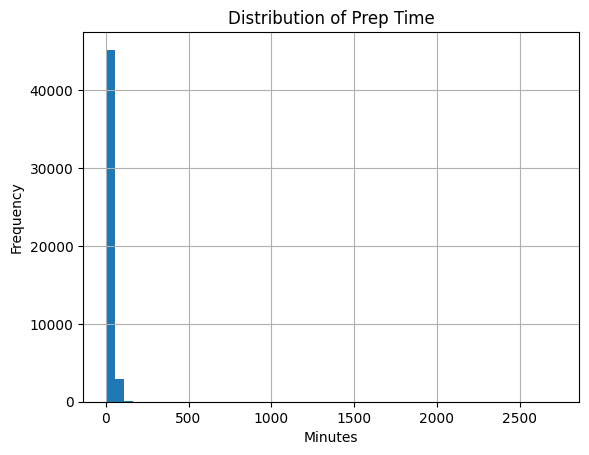

In [60]:
# Distribution shape
plt.figure()
df["prep_time_minutes"].hist(bins=50)
plt.title("Distribution of Prep Time")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

In [61]:
df["prep_time_minutes"].quantile([0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

0.00     0.010944
0.25    13.650094
0.50    21.415852
0.75    33.177619
0.90    47.269945
0.95    58.440064
0.99    84.526741
Name: prep_time_minutes, dtype: float64

In [63]:
min_val = df["prep_time_minutes"].min()
max_val = df["prep_time_minutes"].max()

bins = np.arange(0, max_val + 100, 100)

df["items_bin"] = pd.cut(df["prep_time_minutes"], bins=bins, right=False)

bin_counts = df["items_bin"].value_counts().sort_index()
bin_counts

items_bin
[0.0, 100.0)        48000
[100.0, 200.0)        176
[200.0, 300.0)          8
[300.0, 400.0)          4
[400.0, 500.0)          2
[500.0, 600.0)          7
[600.0, 700.0)          4
[700.0, 800.0)          3
[800.0, 900.0)          3
[900.0, 1000.0)         1
[1000.0, 1100.0)        7
[1100.0, 1200.0)        3
[1200.0, 1300.0)        0
[1300.0, 1400.0)        2
[1400.0, 1500.0)        2
[1500.0, 1600.0)        1
[1600.0, 1700.0)        2
[1700.0, 1800.0)        2
[1800.0, 1900.0)        1
[1900.0, 2000.0)        2
[2000.0, 2100.0)        0
[2100.0, 2200.0)        0
[2200.0, 2300.0)        2
[2300.0, 2400.0)        0
[2400.0, 2500.0)        1
[2500.0, 2600.0)        0
[2600.0, 2700.0)        0
[2700.0, 2800.0)        1
Name: count, dtype: int64

The question here is are these orders with large prep time indicative of a catering order or are they indicative of corrupted data?

In [68]:
df[df["prep_time_minutes"] > 200][[
    "storeid",
    "cuisine_group",
    "number_of_items",
    "prep_time_minutes"
]].sort_values("prep_time_minutes")

,storeid,cuisine_group,number_of_items,prep_time_minutes
14824,543485,sweets & bakeries,3.0,200.379048
9620,978059,delivery,5.0,205.429455
22992,750122,restaurant,5.0,207.417668
6232,598220,delivery,5.0,269.668624
35341,545558,delivery,5.0,275.032441
46879,715329,sweets & bakeries,3.0,281.691202
6657,161127,delivery,3.0,291.257182
2554,365277,quick restaurant service,4.0,291.815161
25278,119450,delivery,5.0,308.164480
21208,493436,quick restaurant service,2.0,346.677088


In [71]:
df = df.drop(columns=["items_bin"])

In [69]:
df = df[df["prep_time_minutes"] <= 200]

In [73]:
# sanity check
df.shape

(48176, 10)

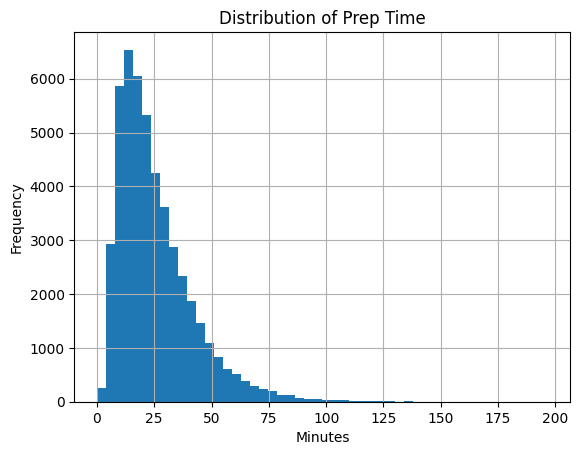

In [74]:
# Distribution shape
plt.figure()
df["prep_time_minutes"].hist(bins=50)
plt.title("Distribution of Prep Time")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

## 3. EDA

The goal of EDA is to understand what drives variance in ``prep_time_minutes`` so we can engineer the right features and flag data quality issues before modeling. The strategy I will follow is as follows:

1. Target distribution — understand the shape, skew, and outliers of the target variabe
2. Univariate feature analysis — distribution of each predictor
3. Bivariate analysis — how each feature relates to prep time
4. Feature interaction hints — catch multivariate patterns that matter for the model

### 3.1 Target distribution 

In [79]:
df["prep_time_minutes"].describe()

count    48176.000000
mean        25.583192
std         16.799247
min          0.010944
25%         13.639576
50%         21.395782
75%         33.123897
max        196.715083
Name: prep_time_minutes, dtype: float64

<Axes: >

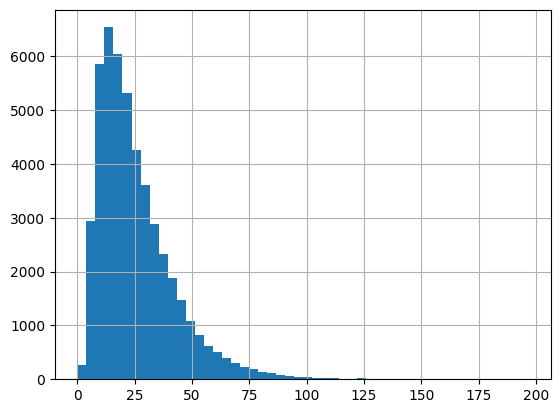

In [78]:
df["prep_time_minutes"].hist(bins=50)

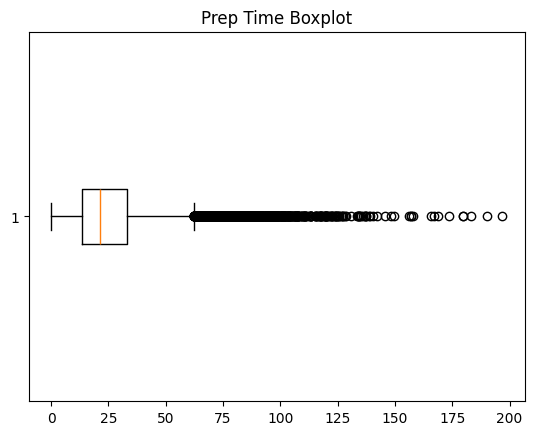

In [87]:
plt.boxplot(df["prep_time_minutes"], vert=False)
plt.title("Prep Time Boxplot")
plt.show()

array([[<Axes: title={'center': 'number_of_items'}>,
        <Axes: title={'center': 'store_age'}>]], dtype=object)

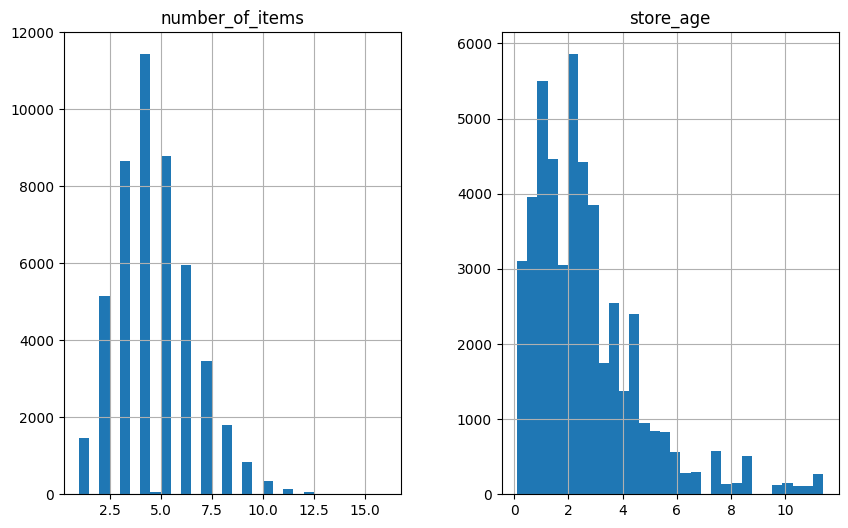

In [81]:
df[["number_of_items", "store_age"]].hist(bins=30, figsize=(10,6))

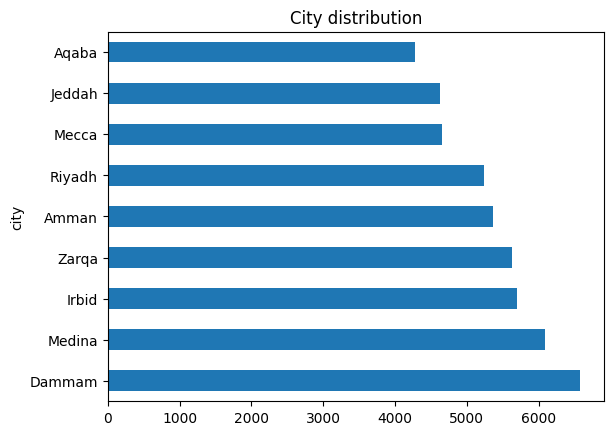

In [82]:
df["city"].value_counts().plot(kind="barh")
plt.title("City distribution")
plt.show()

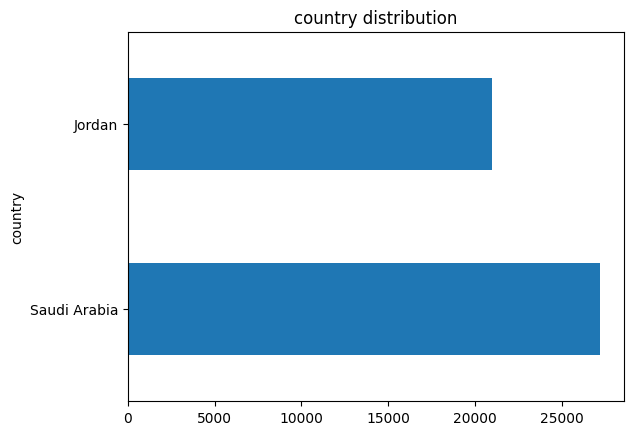

In [83]:
df["country"].value_counts().plot(kind="barh")
plt.title("country distribution")
plt.show()

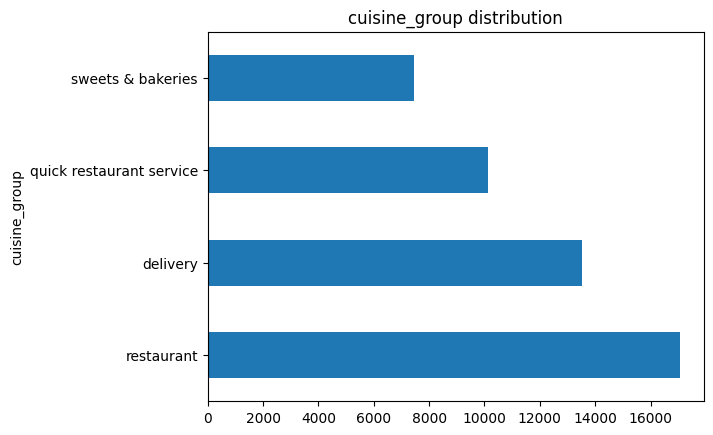

In [84]:
df["cuisine_group"].value_counts().plot(kind="barh")
plt.title("cuisine_group distribution")
plt.show()

In [85]:
df["storeid"].value_counts().describe()

count    350.000000
mean     137.645714
std       12.313022
min      101.000000
25%      129.000000
50%      136.500000
75%      146.000000
max      173.000000
Name: count, dtype: float64

In [86]:
df.to_csv("/Users/raghad/Desktop/clean_data.csv", index=False)

### 3.2 Univariate feature analysis

### 3.2 Bivariate analysis

### 3.4 Feature interaction hints

## 4. Feature Engineering

In [ ]:
df["hour"] = df["requested_delivery_time"].dt.hour
df["day_of_week"] = df["requested_delivery_time"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([4, 5, 6]).astype(int)
df["month"] = df["requested_delivery_time"].dt.month